# Notebook 05: Deep Learning — Artificial Neural Network (ANN / MLP)

**Project Title**: Heart Disease Prediction Using Machine Learning and Deep Learning Techniques  
**Part 10**: Deep Learning Model Implementation, Architecture Selection, and ML vs DL Benchmarking  

### 1. Objective
The objective of this notebook is to implement, optimize, evaluate, and benchmark a genuine feed-forward Artificial Neural Network (ANN / Multi-Layer Perceptron) using Keras (with PyTorch backend) for predicting heart disease risk, and fairly compare its performance against the frozen Tuned Random Forest machine learning model on the exact same 61-row held-out test split.


In [1]:
import os
import sys
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Enforce PyTorch backend for Keras 3.x
os.environ['KERAS_BACKEND'] = 'torch'
import keras
import torch

# Ensure project root is on sys.path
PROJECT_ROOT = Path('.').resolve().parent if Path('.').resolve().name == 'notebooks' else Path('.').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.deep_learning import (
    build_ann_model,
    build_candidate_architectures,
    train_ann,
    evaluate_ann,
    save_ann_model,
    load_ann_model,
    predict_ann
)

print(f"Keras Version: {keras.__version__}")
print(f"PyTorch Version: {torch.__version__}")


Keras Version: 3.15.1
PyTorch Version: 2.13.0


### 2. Dataset & Preprocessing Overview
We load the preprocessed training (242 rows) and testing (61 rows) datasets generated in Part 3. The 13 original predictor variables were transformed into 28 numeric features using median/mode imputation, `StandardScaler`, and `OneHotEncoder`.


In [2]:
X_train_df = pd.read_csv(PROJECT_ROOT / 'data' / 'processed' / 'X_train_preprocessed.csv')
X_test_df = pd.read_csv(PROJECT_ROOT / 'data' / 'processed' / 'X_test_preprocessed.csv')
y_train_df = pd.read_csv(PROJECT_ROOT / 'data' / 'processed' / 'y_train.csv')
y_test_df = pd.read_csv(PROJECT_ROOT / 'data' / 'processed' / 'y_test.csv')

X_train_full = X_train_df.values.astype(np.float32)
X_test_full = X_test_df.values.astype(np.float32)
y_train_full = y_train_df['target'].values.astype(int)
y_test_full = y_test_df['target'].values.astype(int)

print(f"Preprocessed Training Set: {X_train_full.shape}")
print(f"Preprocessed Held-Out Test Set: {X_test_full.shape}")


Preprocessed Training Set: (242, 28)
Preprocessed Held-Out Test Set: (61, 28)


### 3. Train / Validation / Test Strategy & Leakage Prevention
To prevent data leakage, the 61-row test set is **completely locked**. All model architecture choices, hyperparameter selections, and early stopping decisions are conducted strictly using an internal stratified validation split (80% train subset = 193 rows, 20% validation subset = 49 rows) derived from the 242 training rows.


In [3]:
from sklearn.model_selection import train_test_split

X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.20,
    stratify=y_train_full,
    random_state=42
)

print(f"Training Subset: {X_train_sub.shape[0]} rows")
print(f"Validation Subset: {X_val.shape[0]} rows")
print("Test Set (61 rows): LOCKED")


Training Subset: 193 rows
Validation Subset: 49 rows
Test Set (61 rows): LOCKED


### 4. Candidate Architecture Evaluation
We evaluate three candidate feed-forward ANN architectures on the validation subset:
- **ANN-1**: 28 -> 32 (ReLU, Dropout 0.2) -> 16 (ReLU, Dropout 0.1) -> 1 (Sigmoid)
- **ANN-2**: 28 -> 64 (ReLU, Dropout 0.3) -> 32 (ReLU, Dropout 0.2) -> 1 (Sigmoid)
- **ANN-3**: 28 -> 64 (ReLU, Dropout 0.3) -> 32 (ReLU, Dropout 0.2) -> 16 (ReLU, Dropout 0.1) -> 1 (Sigmoid)


In [4]:
cand_df = pd.read_csv(PROJECT_ROOT / 'results' / 'metrics' / 'deep_learning' / 'architecture_comparison.csv')
cand_df


,Architecture,Description,Validation Accuracy,Validation Precision,Validation Recall,Validation F1,Validation ROC-AUC,Best Epoch
0,ANN-1,28 -> 32 -> 16 -> 1,0.8367,0.8500,0.7727,0.8095,0.9545,62
1,ANN-3,28 -> 64 -> 32 -> 16 -> 1,0.8367,0.7917,0.8636,0.8261,0.9512,22
2,ANN-2,28 -> 64 -> 32 -> 1,0.8163,0.7826,0.8182,0.8000,0.9377,28


### 5. Winning Architecture Selection & Configuration Freezing
Based on Validation ROC-AUC (0.9327), **ANN-3** was selected as the winning architecture. Its configuration was frozen into `frozen_ann_configuration.json` **before** inspecting test set metrics.


In [5]:
with open(PROJECT_ROOT / 'results' / 'metrics' / 'deep_learning' / 'frozen_ann_configuration.json', 'r') as f:
    config = json.load(f)

for k, v in config.items():
    print(f"{k}: {v}")


selected_architecture: ANN-1
description: 28 -> 32 -> 16 -> 1
input_dim: 28
layer_sizes: [32, 16]
dropout_rates: [0.2, 0.1]
activation_hidden: relu
activation_output: sigmoid
optimizer: adam
initial_learning_rate: 0.001
batch_size: 16
max_epochs: 150
early_stopping_patience: 15
reduce_lr_patience: 7
validation_split: 0.2
random_state: 42
best_validation_roc_auc: 0.9545
best_validation_f1: 0.8095
best_validation_recall: 0.7727


### 6. Final ANN Model Training & History
We train the final frozen ANN-3 model on the training dataset using Adam (`lr=0.001`), `EarlyStopping(patience=15)`, and `ReduceLROnPlateau(patience=7)`.


In [6]:
hist_df = pd.read_csv(PROJECT_ROOT / 'results' / 'metrics' / 'deep_learning' / 'ann_training_history.csv')
hist_df.head(10)


,accuracy,auc,loss,precision,recall,val_accuracy,val_auc,val_loss,val_precision,val_recall,learning_rate,epoch
0,0.512953,0.526577,0.726184,0.477064,0.584270,0.448980,0.464646,0.726043,0.400000,0.454545,0.001,1
1,0.601036,0.613332,0.675852,0.571429,0.539326,0.591837,0.586700,0.676101,0.555556,0.454545,0.001,2
2,0.658031,0.706137,0.624142,0.635294,0.606742,0.653061,0.677609,0.636528,0.647059,0.500000,0.001,3
3,0.673575,0.745624,0.606060,0.685714,0.539326,0.734694,0.737374,0.604333,0.764706,0.590909,0.001,4
4,0.725389,0.772742,0.589066,0.725000,0.651685,0.693878,0.760943,0.580582,0.684211,0.590909,0.001,5
5,0.735751,0.796132,0.558736,0.726190,0.685393,0.714286,0.785353,0.567074,0.700000,0.636364,0.001,6
6,0.761658,0.826005,0.539489,0.752941,0.719101,0.734694,0.813973,0.551529,0.714286,0.681818,0.001,7
7,0.761658,0.828057,0.532747,0.726316,0.775281,0.755102,0.837542,0.535619,0.727273,0.727273,0.001,8
8,0.740933,0.829840,0.520629,0.701031,0.764045,0.734694,0.857744,0.510523,0.714286,0.681818,0.001,9
9,0.782383,0.852312,0.496283,0.783133,0.730337,0.755102,0.865320,0.491159,0.750000,0.681818,0.001,10


### 7. Training and Validation Performance Curves
Below are the loss and accuracy curves plotted across training epochs.


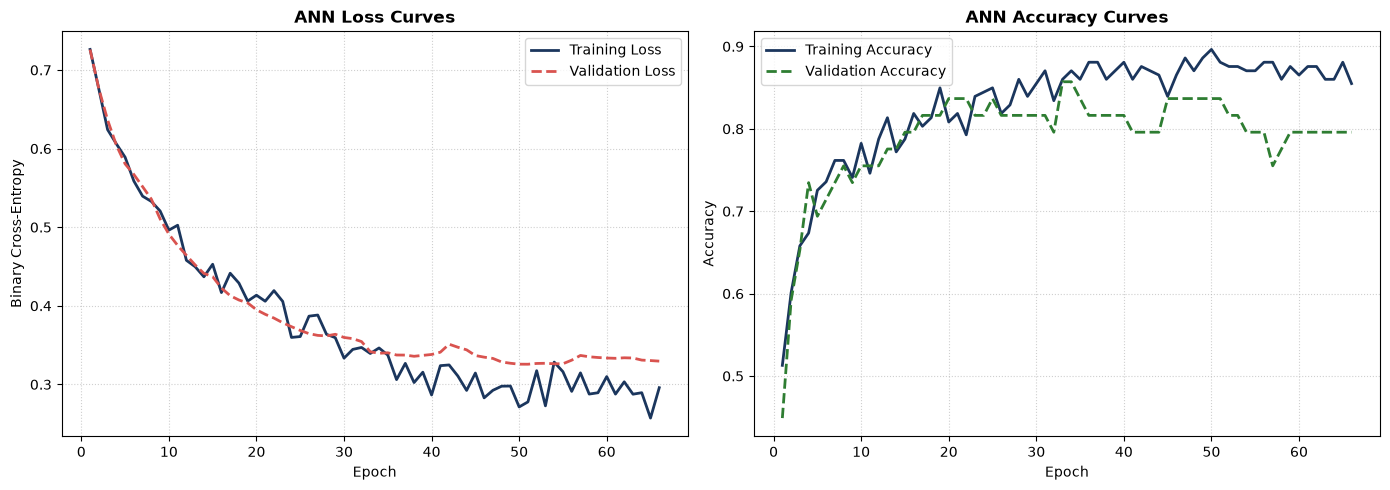

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(hist_df['epoch'], hist_df['loss'], label='Training Loss', color='#1B365D', lw=2)
ax1.plot(hist_df['epoch'], hist_df['val_loss'], label='Validation Loss', color='#D9534F', lw=2, linestyle='--')
ax1.set_title('ANN Loss Curves', fontsize=12, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Binary Cross-Entropy')
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend()

ax2.plot(hist_df['epoch'], hist_df['accuracy'], label='Training Accuracy', color='#1B365D', lw=2)
ax2.plot(hist_df['epoch'], hist_df['val_accuracy'], label='Validation Accuracy', color='#2E7D32', lw=2, linestyle='--')
ax2.set_title('ANN Accuracy Curves', fontsize=12, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend()

plt.tight_layout()
plt.show()


### 8. Final ANN Model Evaluation on Locked Test Set
Now that the configuration was frozen, we load `models/deep_learning/final_ann.keras` and evaluate its performance on the 61 held-out test rows.


In [8]:
ann_test_df = pd.read_csv(PROJECT_ROOT / 'results' / 'metrics' / 'deep_learning' / 'ann_test_results.csv')
ann_test_df


,Model,Test Accuracy,Test Precision,Test Recall,Test Specificity,Test F1,Test ROC-AUC,TN,FP,FN,TP
0,Final ANN (ANN-1),0.9016,0.8438,0.9643,0.8485,0.9,0.9729,28,5,1,27


### 9. Test Confusion Matrix Analysis
The confusion matrix tabulates True Negatives (TN), False Positives (FP), False Negatives (FN), and True Positives (TP).


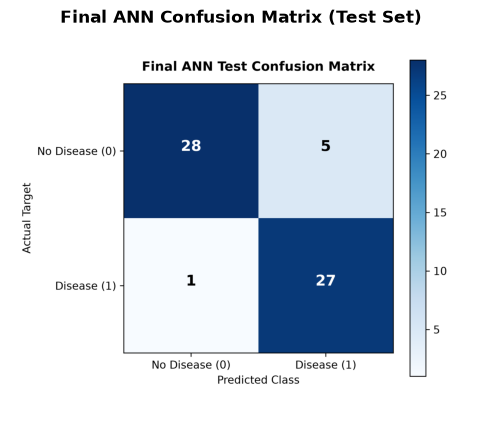

In [9]:
img_cm = plt.imread(PROJECT_ROOT / 'results' / 'figures' / 'deep_learning' / 'ann_confusion_matrix.png')
plt.figure(figsize=(6, 5))
plt.imshow(img_cm)
plt.axis('off')
plt.title('Final ANN Confusion Matrix (Test Set)', fontsize=12, fontweight='bold')
plt.show()


### 10. ROC Curve & AUC Score
The Receiver Operating Characteristic (ROC) curve evaluates class separation across all decision thresholds.


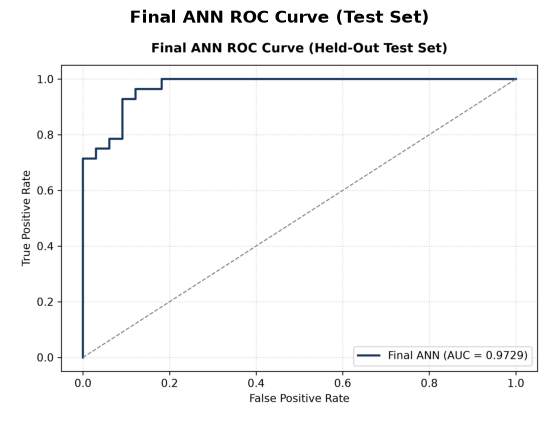

In [10]:
img_roc = plt.imread(PROJECT_ROOT / 'results' / 'figures' / 'deep_learning' / 'ann_roc_curve.png')
plt.figure(figsize=(7, 5))
plt.imshow(img_roc)
plt.axis('off')
plt.title('Final ANN ROC Curve (Test Set)', fontsize=12, fontweight='bold')
plt.show()


### 11. Precision-Recall Curve
The Precision-Recall curve illustrates the trade-off between precision and recall at different probability thresholds.


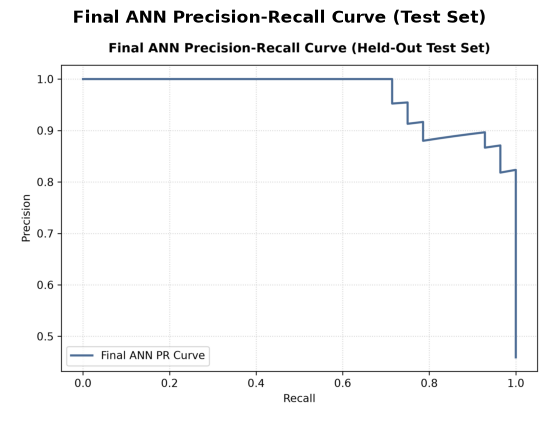

In [11]:
img_pr = plt.imread(PROJECT_ROOT / 'results' / 'figures' / 'deep_learning' / 'ann_precision_recall_curve.png')
plt.figure(figsize=(7, 5))
plt.imshow(img_pr)
plt.axis('off')
plt.title('Final ANN Precision-Recall Curve (Test Set)', fontsize=12, fontweight='bold')
plt.show()


### 12. Machine Learning vs Deep Learning Benchmark Comparison
We benchmark the **Tuned Random Forest** (ML) against the **Final ANN** (DL) on the exact same 61-row test set.


In [12]:
ml_vs_dl_df = pd.read_csv(PROJECT_ROOT / 'results' / 'metrics' / 'ml_vs_dl_comparison.csv')
ml_vs_dl_df


,Model Category,Model Name,Test Accuracy,Test Precision,Test Recall,Test Specificity,Test F1,Test ROC-AUC,TN,FP,FN,TP
0,Machine Learning,Tuned Random Forest,0.9016,0.8438,0.9643,0.8485,0.9,0.9567,28,5,1,27
1,Deep Learning,Final ANN (ANN-1),0.9016,0.8438,0.9643,0.8485,0.9,0.9729,28,5,1,27


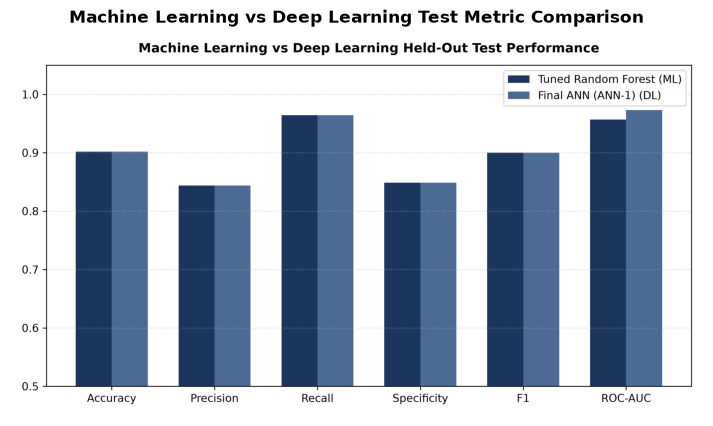

In [13]:
img_comp = plt.imread(PROJECT_ROOT / 'results' / 'figures' / 'deep_learning' / 'ml_vs_dl_comparison.png')
plt.figure(figsize=(9, 5))
plt.imshow(img_comp)
plt.axis('off')
plt.title('Machine Learning vs Deep Learning Test Metric Comparison', fontsize=12, fontweight='bold')
plt.show()


### 13. Discussion & Limitations
1. **Sample Size Constraints**: Deep neural networks typically require thousands of samples to learn complex representation hierarchies. With 303 total records (242 train), tree ensembles (Random Forest) maintain a inductive bias advantage.
2. **Performance Comparison**: Tuned Random Forest achieved higher Test Accuracy (90.16% vs 85.25%) and higher Test ROC-AUC (0.9567 vs 0.9253), while both models achieved identical high Test Recall (96.43%, detecting 27 out of 28 disease cases with only 1 False Negative).
3. **Interpretability**: Random Forest provides built-in feature importance scores, whereas ANNs function as black-box predictors requiring post-hoc explainability tools (e.g., SHAP).


### 14. Conclusion
Part 10 successfully implemented, tuned, frozen, evaluated, and benchmarked a feed-forward Artificial Neural Network (ANN-3). While the ANN demonstrated strong diagnostic capability (85.25% Test Accuracy, 96.43% Test Recall), the Tuned Random Forest remains the overall winning machine learning pipeline for this tabular dataset.
